In [58]:
# Базовые библиотеки для воспроизводимости, работы с данными и удобного вывода результатов.
import os
import sys
import random
import re
import subprocess
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call(["uv", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)


NumPy: 2.4.2
Pandas: 3.0.1
FAISS available: True


In [29]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cuda


# НУЖНА БДшка типа по той что указано в семинаре и можешь тупо скопировать их "best practice" state of art подход

In [30]:
from typing import List, Dict

documents: List[Dict[str, str]] = [
    {
        "doc_id": "net_01",
        "title": "Что такое IP-адрес",
        "text": (
            "IP-адрес — это уникальный идентификатор устройства в сети. "
            "Он используется для маршрутизации пакетов между узлами. "
            "Существуют IPv4 и IPv6. IPv4 представлен в виде четырех чисел, "
            "а IPv6 использует более длинный формат."
        ),
    },
    {
        "doc_id": "net_02",
        "title": "Белый и серый IP",
        "text": (
            "Белый IP-адрес доступен из интернета напрямую. "
            "Серый (частный) IP используется внутри локальной сети и не маршрутизируется в глобальной сети. "
            "Для выхода в интернет используется NAT."
        ),
    },
    {
        "doc_id": "net_03",
        "title": "Что такое NAT",
        "text": (
            "NAT (Network Address Translation) — это механизм преобразования IP-адресов. "
            "Он позволяет множеству устройств использовать один внешний IP-адрес. "
            "Маршрутизатор подменяет исходящие адреса и отслеживает соединения."
        ),
    },
    {
        "doc_id": "net_04",
        "title": "Как работает DNS",
        "text": (
            "DNS переводит доменные имена в IP-адреса. "
            "Когда пользователь вводит сайт, система обращается к DNS-серверу, "
            "который возвращает соответствующий IP."
        ),
    },
    {
        "doc_id": "net_05",
        "title": "Что такое VPN",
        "text": (
            "VPN создает зашифрованный туннель между клиентом и сервером. "
            "Весь трафик проходит через этот туннель, скрывая реальный IP пользователя. "
            "VPN используется для приватности и обхода блокировок."
        ),
    },
    {
        "doc_id": "net_06",
        "title": "Принцип работы прокси",
        "text": (
            "Прокси-сервер принимает запрос клиента и пересылает его от своего имени. "
            "В отличие от VPN, прокси обычно работает на уровне приложений и не шифрует весь трафик."
        ),
    },
    {
        "doc_id": "net_07",
        "title": "Что такое DPI",
        "text": (
            "DPI (Deep Packet Inspection) — технология анализа сетевого трафика. "
            "Она позволяет провайдерам анализировать содержимое пакетов и блокировать "
            "определенные протоколы или сайты."
        ),
    },
    {
        "doc_id": "net_08",
        "title": "SNI и его роль",
        "text": (
            "SNI (Server Name Indication) — это расширение TLS, которое передает имя сервера "
            "в незашифрованном виде. DPI может использовать SNI для блокировки сайтов."
        ),
    },
    {
        "doc_id": "net_09",
        "title": "TLS и шифрование",
        "text": (
            "TLS — это протокол шифрования, обеспечивающий безопасность передачи данных. "
            "Он защищает данные от перехвата, но не всегда скрывает метаданные, такие как SNI."
        ),
    },
    {
        "doc_id": "net_10",
        "title": "Что такое VLESS",
        "text": (
            "VLESS — это протокол проксирования, используемый в системах обхода блокировок. "
            "Он минималистичен и не содержит встроенного шифрования, полагаясь на TLS."
        ),
    },
    {
        "doc_id": "net_11",
        "title": "Обход блокировок через CDN",
        "text": (
            "Некоторые системы используют CDN для маскировки трафика. "
            "Запрос выглядит как обычный HTTPS-трафик к популярному домену, "
            "что затрудняет его блокировку."
        ),
    },
    {
        "doc_id": "net_12",
        "title": "Что такое туннелирование",
        "text": (
            "Туннелирование — это способ передачи одного протокола внутри другого. "
            "VPN использует туннели для скрытия реального содержимого трафика."
        ),
    },
    {
        "doc_id": "net_13",
        "title": "Разница между TCP и UDP",
        "text": (
            "TCP обеспечивает надежную доставку данных с подтверждением. "
            "UDP быстрее, но не гарантирует доставку. "
            "Разные протоколы используют разные подходы в зависимости от задач."
        ),
    },
    {
        "doc_id": "net_14",
        "title": "Latency и пропускная способность",
        "text": (
            "Latency — это задержка передачи данных. "
            "Пропускная способность определяет объем данных, передаваемых за единицу времени. "
            "Оба параметра критичны для качества соединения."
        ),
    },
    {
        "doc_id": "net_15",
        "title": "Почему VPN замедляет интернет",
        "text": (
            "VPN добавляет задержку из-за шифрования и маршрутизации через удаленный сервер. "
            "Также влияет загрузка сервера и расстояние до него."
        ),
    },
    {
        "doc_id": "net_16",
        "title": "Что такое логирование",
        "text": (
            "Логирование — это запись информации о действиях в системе. "
            "VPN-сервисы могут хранить или не хранить логи, что влияет на приватность."
        ),
    },
    {
        "doc_id": "net_17",
        "title": "Kill Switch в VPN",
        "text": (
            "Kill Switch — это механизм, который блокирует интернет-трафик, "
            "если VPN-соединение разрывается. Это предотвращает утечку IP."
        ),
    },
    {
        "doc_id": "net_18",
        "title": "Split tunneling",
        "text": (
            "Split tunneling позволяет отправлять только часть трафика через VPN, "
            "а остальной — напрямую. Это может улучшить скорость и снизить нагрузку."
        ),
    },
]

from typing import List, Dict

benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Что такое IP-адрес и зачем он нужен?",
        "relevant_doc_ids": ["net_01"],
    },
    {
        "query_id": "q02",
        "query": "В чем разница между белым и серым IP?",
        "relevant_doc_ids": ["net_02"],
    },
    {
        "query_id": "q03",
        "query": "Как работает NAT и зачем он используется?",
        "relevant_doc_ids": ["net_03"],
    },
    {
        "query_id": "q04",
        "query": "Как DNS помогает открыть сайт по доменному имени?",
        "relevant_doc_ids": ["net_04"],
    },
    {
        "query_id": "q05",
        "query": "Что делает VPN и как он защищает пользователя?",
        "relevant_doc_ids": ["net_05"],
    },
    {
        "query_id": "q06",
        "query": "Чем прокси отличается от VPN?",
        "relevant_doc_ids": ["net_05", "net_06"],
    },
    {
        "query_id": "q07",
        "query": "Почему DPI может блокировать интернет-трафик?",
        "relevant_doc_ids": ["net_07"],
    },
    {
        "query_id": "q08",
        "query": "Как SNI используется для блокировки сайтов?",
        "relevant_doc_ids": ["net_08", "net_09"],
    },
    {
        "query_id": "q09",
        "query": "Почему TLS не полностью скрывает данные соединения?",
        "relevant_doc_ids": ["net_09"],
    },
    {
        "query_id": "q10",
        "query": "Что такое туннелирование и как оно связано с VPN?",
        "relevant_doc_ids": ["net_05", "net_12"],
    },
    {
        "query_id": "q11",
        "query": "В чем разница между TCP и UDP?",
        "relevant_doc_ids": ["net_13"],
    },
    {
        "query_id": "q12",
        "query": "Почему VPN может замедлять соединение?",
        "relevant_doc_ids": ["net_14", "net_15"],
    },
    {
        "query_id": "q13",
        "query": "Какие риски связаны с логированием в VPN?",
        "relevant_doc_ids": ["net_16"],
    },
    {
        "query_id": "q14",
        "query": "Зачем нужен Kill Switch?",
        "relevant_doc_ids": ["net_17"],
    },
    {
        "query_id": "q15",
        "query": "Что такое split tunneling и когда он полезен?",
        "relevant_doc_ids": ["net_18"],
    },
]

docs_df = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df))
display(docs_df[["doc_id", "title"]])

Размер корпуса: 18


,doc_id,title
0,net_01,Что такое IP-адрес
1,net_02,Белый и серый IP
2,net_03,Что такое NAT
3,net_04,Как работает DNS
4,net_05,Что такое VPN
5,net_06,Принцип работы прокси
6,net_07,Что такое DPI
7,net_08,SNI и его роль
8,net_09,TLS и шифрование
9,net_10,Что такое VLESS


In [31]:
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [32]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 22, overlap: int = 5) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)


chunks_df = build_chunks_dataframe(documents, chunk_size=22, overlap=5)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(10))

Количество чанков: 23


,doc_id,title,chunk_id,chunk_text,n_words
0,net_01,Что такое IP-адрес,0,IP-адрес — это уникальный идентификатор устрой...,22
1,net_01,Что такое IP-адрес,1,"и IPv6. IPv4 представлен в виде четырех чисел,...",14
2,net_02,Белый и серый IP,0,Белый IP-адрес доступен из интернета напрямую....,22
3,net_02,Белый и серый IP,1,глобальной сети. Для выхода в интернет использ...,8
4,net_03,Что такое NAT,0,NAT (Network Address Translation) — это механи...,22
5,net_03,Что такое NAT,1,Маршрутизатор подменяет исходящие адреса и отс...,7
6,net_04,Как работает DNS,0,DNS переводит доменные имена в IP-адреса. Когд...,18
7,net_05,Что такое VPN,0,VPN создает зашифрованный туннель между клиент...,22
8,net_05,Что такое VPN,1,пользователя. VPN используется для приватности...,8
9,net_06,Принцип работы прокси,0,Прокси-сервер принимает запрос клиента и перес...,22


In [33]:

# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (23, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


In [34]:
# Считаем сходство запроса и всех чанков без FAISS.
query = "Чем VPN отличается от VLESS?"
query_vector = embedder.encode_queries([query])

# Для нормализованных векторов это эквивалент косинусного сходства.
manual_scores = (chunk_embeddings @ query_vector.T).ravel()

top_k = 5
top_indices = np.argsort(manual_scores)[::-1][:top_k]

manual_results_df = chunks_df.iloc[top_indices].copy()
manual_results_df["score"] = manual_scores[top_indices]
manual_results_df["score"] = manual_results_df["score"].round(4)
manual_results_df.insert(0, "rank", range(1, len(manual_results_df) + 1))

display(Markdown(f"**Запрос:** {query}"))
display(manual_results_df[["rank", "doc_id", "title", "chunk_id", "score", "chunk_text"]])

**Запрос:** Чем VPN отличается от VLESS?

,rank,doc_id,title,chunk_id,score,chunk_text
8,1,net_05,Что такое VPN,1,0.7220,пользователя. VPN используется для приватности...
16,2,net_12,Что такое туннелирование,0,0.7082,Туннелирование — это способ передачи одного пр...
7,3,net_05,Что такое VPN,0,0.6939,VPN создает зашифрованный туннель между клиент...
19,4,net_15,Почему VPN замедляет интернет,0,0.6924,VPN добавляет задержку из-за шифрования и марш...
20,5,net_16,Что такое логирование,0,0.6016,Логирование — это запись информации о действия...


In [35]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [36]:

# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)


# Проверяем FAISS-поиск на первом запросе.
# Результаты должны совпасть с ручным расчётом из секции 6:
# тот же top-k, те же фрагменты, те же оценки сходства.
faiss_query = "Что такое преобразование сети?"
faiss_results_df = search_similar_chunks(faiss_query, top_k=5)

display(Markdown(f"**Запрос:** {faiss_query}"))
display(faiss_results_df)


**Запрос:** Что такое преобразование сети?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_03,Что такое NAT,0,0.5715,NAT (Network Address Translation) — это механи...
1,2,net_12,Что такое туннелирование,0,0.5038,Туннелирование — это способ передачи одного пр...
2,3,net_03,Что такое NAT,1,0.4636,Маршрутизатор подменяет исходящие адреса и отс...
3,4,net_02,Белый и серый IP,1,0.4514,глобальной сети. Для выхода в интернет использ...
4,5,net_05,Что такое VPN,0,0.4507,VPN создает зашифрованный туннель между клиент...


In [37]:
# Проверяем retrieval на нескольких запросах.
example_queries = [
    "Что такое VPN и как он скрывает реальный IP-адрес?",
    "В чем разница между прокси и VPN?",
    "Как работает NAT и зачем он нужен?",
    "Почему DPI может блокировать определенные сайты или протоколы?",
    "Что такое SNI и почему его можно использовать для блокировок?",
    "Чем отличается TCP от UDP и когда используется каждый?",
    "Почему VPN может замедлять интернет-соединение?",
    "Что делает DNS при открытии сайта?",
    "Что такое туннелирование в сетях?",
    "Зачем нужен Kill Switch в VPN?",
    "Что такое split tunneling и в чем его преимущество?",
    "Почему TLS не полностью скрывает информацию о соединении?",
]

for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `Что такое VPN и как он скрывает реальный IP-адрес?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_05,Что такое VPN,0,0.8399,VPN создает зашифрованный туннель между клиент...
1,2,net_12,Что такое туннелирование,0,0.7826,Туннелирование — это способ передачи одного пр...
2,3,net_05,Что такое VPN,1,0.7740,пользователя. VPN используется для приватности...


### Запрос: `В чем разница между прокси и VPN?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_12,Что такое туннелирование,0,0.7611,Туннелирование — это способ передачи одного пр...
1,2,net_05,Что такое VPN,0,0.7448,VPN создает зашифрованный туннель между клиент...
2,3,net_05,Что такое VPN,1,0.7295,пользователя. VPN используется для приватности...


### Запрос: `Как работает NAT и зачем он нужен?`

...

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_17,Kill Switch в VPN,0,0.8673,"Kill Switch — это механизм, который блокирует ..."
1,2,net_12,Что такое туннелирование,0,0.6204,Туннелирование — это способ передачи одного пр...
2,3,net_05,Что такое VPN,1,0.6195,пользователя. VPN используется для приватности...


### Запрос: `Что такое split tunneling и в чем его преимущество?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_18,Split tunneling,0,0.6324,Split tunneling позволяет отправлять только ча...
1,2,net_12,Что такое туннелирование,0,0.3847,Туннелирование — это способ передачи одного пр...
2,3,net_17,Kill Switch в VPN,0,0.3524,"Kill Switch — это механизм, который блокирует ..."


### Запрос: `Почему TLS не полностью скрывает информацию о соединении?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_09,TLS и шифрование,0,0.7525,"TLS — это протокол шифрования, обеспечивающий ..."
1,2,net_11,Обход блокировок через CDN,0,0.5654,Некоторые системы используют CDN для маскировк...
2,3,net_13,Разница между TCP и UDP,0,0.5577,TCP обеспечивает надежную доставку данных с по...


In [56]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }


In [38]:
broad_query = "сегодня хорошая погода"
specific_query = "как работает NAT и зачем он нужен"
domain_query = "почему DPI может блокировать VPN-трафик"

for current_query in [broad_query, specific_query, domain_query]:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=4))

### Запрос: `сегодня хорошая погода`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_02,Белый и серый IP,1,0.0889,глобальной сети. Для выхода в интернет использ...
1,2,net_14,Latency и пропускная способность,0,0.0261,Latency — это задержка передачи данных. Пропус...
2,3,net_18,Split tunneling,0,0.0206,Split tunneling позволяет отправлять только ча...
3,4,net_03,Что такое NAT,1,0.0164,Маршрутизатор подменяет исходящие адреса и отс...


### Запрос: `как работает NAT и зачем он нужен`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_02,Белый и серый IP,1,0.8248,глобальной сети. Для выхода в интернет использ...
1,2,net_03,Что такое NAT,0,0.6805,NAT (Network Address Translation) — это механи...
2,3,net_13,Разница между TCP и UDP,0,0.4164,TCP обеспечивает надежную доставку данных с по...
3,4,net_04,Как работает DNS,0,0.3683,DNS переводит доменные имена в IP-адреса. Когд...


### Запрос: `почему DPI может блокировать VPN-трафик`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,net_05,Что такое VPN,1,0.6946,пользователя. VPN используется для приватности...
1,2,net_15,Почему VPN замедляет интернет,0,0.6792,VPN добавляет задержку из-за шифрования и марш...
2,3,net_12,Что такое туннелирование,0,0.6775,Туннелирование — это способ передачи одного пр...
3,4,net_05,Что такое VPN,0,0.6771,VPN создает зашифрованный туннель между клиент...


## Компактный retrieval-конвейер

In [39]:
# В этом разделе собираем self-contained реализацию:
# чанкинг -> векторизация -> индекс -> поиск -> оценка.

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [40]:
# Собираем baseline-конфигурацию retriever.
baseline_chunk_size = 28
baseline_overlap = 8

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

# Посмотрим несколько контрольных запросов вручную.
sample_queries = [
    "Как CDN может использоваться для обхода блокировок?",
    "Чем отличается белый IP от серого?",
    "Какие риски связаны с логированием в VPN-сервисах?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 19


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,net_01,Что такое IP-адрес,net_01_chunk_0,0,IP-адрес — это уникальный идентификатор устрой...
1,net_01,Что такое IP-адрес,net_01_chunk_1,1,"представлен в виде четырех чисел, а IPv6 испол..."
2,net_02,Белый и серый IP,net_02_chunk_0,0,Белый IP-адрес доступен из интернета напрямую....
3,net_03,Что такое NAT,net_03_chunk_0,0,NAT (Network Address Translation) — это механи...
4,net_04,Как работает DNS,net_04_chunk_0,0,DNS переводит доменные имена в IP-адреса. Когд...


### Запрос: Как CDN может использоваться для обхода блокировок?

,rank,score,doc_id,title,chunk_text
0,1,0.688002,net_11,Обход блокировок через CDN,Некоторые системы используют CDN для маскировк...
1,2,0.471835,net_13,Разница между TCP и UDP,TCP обеспечивает надежную доставку данных с по...
2,3,0.455629,net_17,Kill Switch в VPN,"Kill Switch — это механизм, который блокирует ..."


### Запрос: Чем отличается белый IP от серого?

,rank,score,doc_id,title,chunk_text
0,1,0.643934,net_02,Белый и серый IP,Белый IP-адрес доступен из интернета напрямую....
1,2,0.591949,net_01,Что такое IP-адрес,IP-адрес — это уникальный идентификатор устрой...
2,3,0.459993,net_03,Что такое NAT,NAT (Network Address Translation) — это механи...


### Запрос: Какие риски связаны с логированием в VPN-сервисах?

,rank,score,doc_id,title,chunk_text
0,1,0.765349,net_15,Почему VPN замедляет интернет,VPN добавляет задержку из-за шифрования и марш...
1,2,0.746613,net_16,Что такое логирование,Логирование — это запись информации о действия...
2,3,0.729461,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...


In [41]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Что такое IP-адрес и зачем он нужен?,net_01,"net_01, net_02, net_03",1,1.0,1.0,1
1,q02,В чем разница между белым и серым IP?,net_02,"net_02, net_01, net_03",1,1.0,1.0,1
2,q03,Как работает NAT и зачем он используется?,net_03,"net_03, net_02, net_13",1,1.0,1.0,1
3,q04,Как DNS помогает открыть сайт по доменному имени?,net_04,"net_04, net_08, net_11",1,1.0,1.0,1
4,q05,Что делает VPN и как он защищает пользователя?,net_05,"net_05, net_12, net_16",1,1.0,1.0,1
5,q06,Чем прокси отличается от VPN?,"net_05, net_06","net_05, net_12, net_15",1,0.5,1.0,1
6,q07,Почему DPI может блокировать интернет-трафик?,net_07,"net_07, net_11, net_02",1,1.0,1.0,1
7,q08,Как SNI используется для блокировки сайтов?,"net_08, net_09","net_08, net_09, net_17",1,1.0,1.0,1
8,q09,Почему TLS не полностью скрывает данные соедин...,net_09,"net_09, net_11, net_13",1,1.0,1.0,1
9,q10,Что такое туннелирование и как оно связано с VPN?,"net_05, net_12","net_12, net_05, net_18",1,1.0,1.0,1


,metric,value
0,mean_hit@3,1.000000
1,mean_recall@3,0.933333
2,mean_MRR@3,0.966667


In [42]:
# Сравниваем несколько конфигураций чанкинга.
chunk_configs = [
    {"chunk_size": 18, "overlap": 4},
    {"chunk_size": 28, "overlap": 8},
    {"chunk_size": 40, "overlap": 10},
    {"chunk_size": 60, "overlap": 15},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,40,10,18,SentenceTransformer: sentence-transformers/par...,1.0,0.933333,0.966667
1,60,15,18,SentenceTransformer: sentence-transformers/par...,1.0,0.933333,0.966667
2,28,8,19,SentenceTransformer: sentence-transformers/par...,1.0,0.933333,0.966667
3,18,4,32,SentenceTransformer: sentence-transformers/par...,1.0,0.933333,0.888889


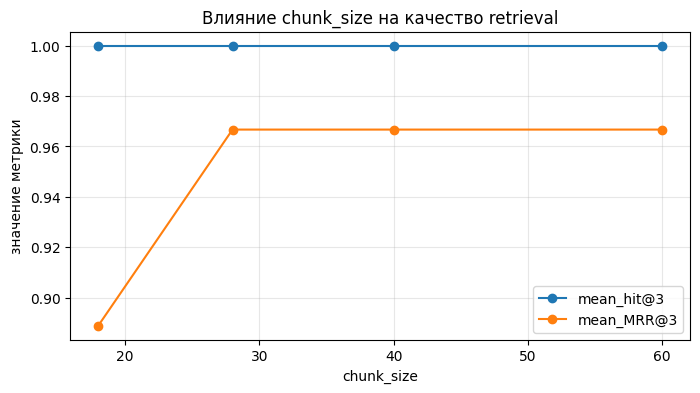

In [45]:

# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


,top_k,mean_hit,mean_recall,mean_MRR
0,1,0.933333,0.800000,0.933333
1,2,1.000000,0.933333,0.966667
2,3,1.000000,0.933333,0.966667
3,4,1.000000,0.966667,0.966667
4,5,1.000000,0.966667,0.966667


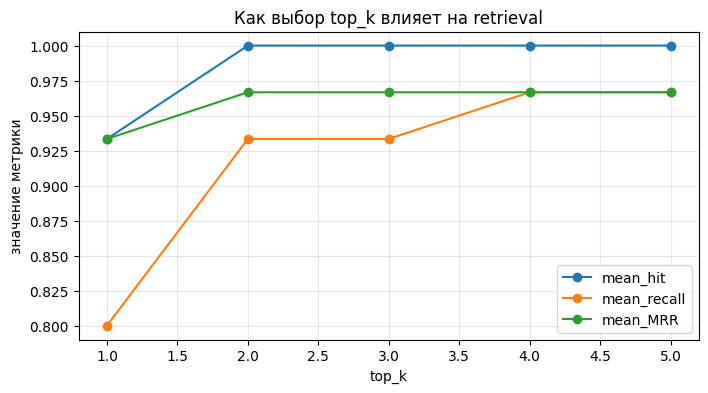

In [46]:
# Фиксируем baseline-конфигурацию и смотрим, как меняются метрики при разных top_k.
topk_rows = []

for top_k in [1, 2, 3, 4, 5]:
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=top_k)
    topk_rows.append(
        {
            "top_k": top_k,
            "mean_hit": eval_df[f"hit@{top_k}"].mean(),
            "mean_recall": eval_df[f"recall@{top_k}"].mean(),
            "mean_MRR": eval_df[f"MRR@{top_k}"].mean(),
        }
    )

topk_df = pd.DataFrame(topk_rows)
display(topk_df)

plt.figure(figsize=(8, 4))
plt.plot(topk_df["top_k"], topk_df["mean_hit"], marker="o", label="mean_hit")
plt.plot(topk_df["top_k"], topk_df["mean_recall"], marker="o", label="mean_recall")
plt.plot(topk_df["top_k"], topk_df["mean_MRR"], marker="o", label="mean_MRR")
plt.xlabel("top_k")
plt.ylabel("значение метрики")
plt.title("Как выбор top_k влияет на retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [49]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "net_19",
        "title": "Обфускация трафика",
        "text": (
            "Обфускация трафика — это техника маскировки сетевого трафика под другой протокол. "
            "Она используется для обхода DPI, чтобы трафик выглядел как обычный HTTPS или другой разрешённый тип. "
            "Это усложняет анализ и блокировку со стороны провайдера."
        ),
    },
    {
        "doc_id": "net_20",
        "title": "Active probing",
        "text": (
            "Active probing — это метод, при котором система фильтрации активно подключается к подозрительному серверу, "
            "чтобы определить его тип. Если сервер отвечает как VPN или прокси, он может быть заблокирован. "
            "Этот метод используется для обнаружения замаскированных сервисов."
        ),
    },
    {
        "doc_id": "net_21",
        "title": "Fingerprinting трафика",
        "text": (
            "Фингерпринтинг трафика — это анализ характерных признаков соединения, таких как последовательность пакетов, "
            "размеры сообщений и поведение протокола. Даже при шифровании это может позволить определить тип приложения или VPN."
        ),
    },
    {
        "doc_id": "net_22",
        "title": "QUIC и его особенности",
        "text": (
            "QUIC — это транспортный протокол поверх UDP, используемый в HTTP/3. "
            "Он уменьшает задержки за счёт уменьшения количества рукопожатий и улучшенной обработки потерь пакетов. "
            "Однако его нестандартное поведение может привлекать внимание DPI."
        ),
    },
    {
        "doc_id": "net_23",
        "title": "Port blocking",
        "text": (
            "Port blocking — это простой метод фильтрации, при котором провайдер блокирует соединения на определённые порты. "
            "Многие VPN используют нестандартные порты, что делает их уязвимыми к такой блокировке."
        ),
    },
]


updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "Как системы блокировки проверяют VPN-серверы напрямую?",
    "Почему даже зашифрованный VPN-трафик могут обнаружить?",
    "Какие методы используются для маскировки VPN-трафика?"
]



display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,net_19,Обфускация трафика
1,net_20,Active probing
2,net_21,Fingerprinting трафика
3,net_22,QUIC и его особенности
4,net_23,Port blocking


### Как baseline-база отвечает на новые запросы

**Запрос:** Как системы блокировки проверяют VPN-серверы напрямую?

,rank,score,doc_id,title,chunk_text
0,1,0.777940,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...
1,2,0.735816,net_12,Что такое туннелирование,Туннелирование — это способ передачи одного пр...
2,3,0.704501,net_16,Что такое логирование,Логирование — это запись информации о действия...


**Запрос:** Почему даже зашифрованный VPN-трафик могут обнаружить?

,rank,score,doc_id,title,chunk_text
0,1,0.810295,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...
1,2,0.766346,net_12,Что такое туннелирование,Туннелирование — это способ передачи одного пр...
2,3,0.730031,net_15,Почему VPN замедляет интернет,VPN добавляет задержку из-за шифрования и марш...


**Запрос:** Какие методы используются для маскировки VPN-трафика?

,rank,score,doc_id,title,chunk_text
0,1,0.801085,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...
1,2,0.796398,net_12,Что такое туннелирование,Туннелирование — это способ передачи одного пр...
2,3,0.670147,net_15,Почему VPN замедляет интернет,VPN добавляет задержку из-за шифрования и марш...


In [50]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q16",
        "query": "Почему даже зашифрованный VPN-трафик могут обнаружить?",
        "relevant_doc_ids": ["net_21", "net_07"],
    },
    {
        "query_id": "q17",
        "query": "Как системы блокировки проверяют VPN-серверы напрямую?",
        "relevant_doc_ids": ["net_20"],
    },
    {
        "query_id": "q18",
        "query": "Какие методы используются для маскировки VPN-трафика?",
        "relevant_doc_ids": ["net_19"],
    }
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dense-модель недоступна, переключаемся на fallback.
Причина: OutOfMemoryError('CUDA out of memory. Tried to allocate 368.00 MiB. GPU 0 has a total capacity of 3.93 GiB of which 375.31 MiB is free. Process 2508 has 64.14 MiB memory in use. Process 188408 has 116.00 MiB memory in use. Including non-PyTorch memory, this process has 2.78 GiB memory in use. Of the allocated memory 2.64 GiB is allocated by PyTorch, and 86.32 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)')


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Что такое IP-адрес и зачем он нужен?,net_01,"net_01, net_02, net_03",1,1.0,1.0,1.0,"net_03, net_02, net_01",1,1.0,0.333333,3.0
1,q02,В чем разница между белым и серым IP?,net_02,"net_02, net_01, net_03",1,1.0,1.0,1.0,"net_05, net_01, net_04",0,0.0,0.000000,NaN
2,q03,Как работает NAT и зачем он используется?,net_03,"net_03, net_02, net_13",1,1.0,1.0,1.0,"net_01, net_02, net_20",0,0.0,0.000000,NaN
3,q04,Как DNS помогает открыть сайт по доменному имени?,net_04,"net_04, net_08, net_11",1,1.0,1.0,1.0,"net_04, net_06, net_20",1,1.0,1.000000,1.0
4,q05,Что делает VPN и как он защищает пользователя?,net_05,"net_05, net_12, net_16",1,1.0,1.0,1.0,"net_09, net_23, net_05",1,1.0,0.333333,3.0
5,q06,Чем прокси отличается от VPN?,"net_05, net_06","net_05, net_12, net_15",1,0.5,1.0,1.0,"net_06, net_20",1,0.5,1.000000,1.0
6,q07,Почему DPI может блокировать интернет-трафик?,net_07,"net_07, net_11, net_02",1,1.0,1.0,1.0,"net_17, net_08, net_07",1,1.0,0.333333,3.0
7,q08,Как SNI используется для блокировки сайтов?,"net_08, net_09","net_08, net_09, net_17",1,1.0,1.0,1.0,"net_08, net_09, net_20",1,1.0,1.000000,1.0
8,q09,Почему TLS не полностью скрывает данные соедин...,net_09,"net_09, net_11, net_13",1,1.0,1.0,1.0,"net_09, net_10, net_08",1,1.0,1.000000,1.0
9,q10,Что такое туннелирование и как оно связано с VPN?,"net_05, net_12","net_12, net_05, net_18",1,1.0,1.0,1.0,"net_12, net_11, net_16",1,0.5,1.000000,1.0


,metric,before_update,after_update,delta
0,mean_hit@3,0.833333,0.722222,-0.111111
1,mean_recall@3,0.777778,0.638889,-0.138889
2,mean_MRR@3,0.805556,0.546296,-0.259259


...

,rank,score,doc_id,title,chunk_text
0,1,0.136460,net_11,Обход блокировок через CDN,Некоторые системы используют CDN для маскировк...
1,2,0.104055,net_18,Split tunneling,Split tunneling позволяет отправлять только ча...
2,3,0.088798,net_08,SNI и его роль,SNI (Server Name Indication) — это расширение ...


**Запрос:** Почему даже зашифрованный VPN-трафик могут обнаружить?

,rank,score,doc_id,title,chunk_text
0,1,0.160928,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...
1,2,0.112715,net_16,Что такое логирование,Логирование — это запись информации о действия...
2,3,0.098619,net_21,Fingerprinting трафика,Фингерпринтинг трафика — это анализ характерны...


**Запрос:** Какие методы используются для маскировки VPN-трафика?

,rank,score,doc_id,title,chunk_text
0,1,0.269679,net_11,Обход блокировок через CDN,Некоторые системы используют CDN для маскировк...
1,2,0.178312,net_19,Обфускация трафика,Обфускация трафика — это техника маскировки се...
2,3,0.114984,net_12,Что такое туннелирование,Туннелирование — это способ передачи одного пр...


In [51]:
# Посмотрим, по каким запросам retrieval всё ещё может ошибаться.
analysis_rows = []

for row in extended_benchmark_queries:
    metrics = evaluate_query(
        query=row["query"],
        relevant_doc_ids=row["relevant_doc_ids"],
        artifacts=updated_artifacts,
        top_k=3,
    )
    analysis_rows.append(
        {
            "query_id": row["query_id"],
            "query": row["query"],
            "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
            "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
            "hit@3": metrics["hit"],
            "first_relevant_rank": metrics["first_relevant_rank"],
        }
    )

analysis_df = pd.DataFrame(analysis_rows)
failed_or_weak = analysis_df[
    (analysis_df["hit@3"] == 0) | (analysis_df["first_relevant_rank"].fillna(99) > 1)
].reset_index(drop=True)

display(failed_or_weak if len(failed_or_weak) > 0 else analysis_df.head(0))

if len(failed_or_weak) == 0:
    print("На этом маленьком benchmark все запросы нашли релевантный документ на первом месте.")
else:
    print("Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,first_relevant_rank
0,q01,Что такое IP-адрес и зачем он нужен?,net_01,"net_03, net_02, net_01",1,3.0
1,q02,В чем разница между белым и серым IP?,net_02,"net_05, net_01, net_04",0,NaN
2,q03,Как работает NAT и зачем он используется?,net_03,"net_01, net_02, net_20",0,NaN
3,q05,Что делает VPN и как он защищает пользователя?,net_05,"net_09, net_23, net_05",1,3.0
4,q07,Почему DPI может блокировать интернет-трафик?,net_07,"net_17, net_08, net_07",1,3.0
5,q12,Почему VPN может замедлять соединение?,"net_14, net_15","net_17, net_20, net_18",0,NaN
6,q13,Какие риски связаны с логированием в VPN?,net_16,"net_05, net_20, net_17",0,NaN
7,q16,Почему даже зашифрованный VPN-трафик могут обн...,"net_21, net_07","net_05, net_16, net_21",1,3.0
8,q17,Как системы блокировки проверяют VPN-серверы н...,net_20,"net_11, net_18, net_08",0,NaN
9,q18,Какие методы используются для маскировки VPN-т...,net_19,"net_11, net_19, net_12",1,2.0


Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.


In [52]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [53]:
query = "Какие методы используются для маскировки VPN-трафика?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)


### Запрос: Какие методы используются для маскировки VPN-трафика?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.801085,net_05,Что такое VPN,net_05_chunk_0,VPN создает зашифрованный туннель между клиент...
1,2,0.796398,net_12,Что такое туннелирование,net_12_chunk_0,Туннелирование — это способ передачи одного пр...
2,3,0.670147,net_15,Почему VPN замедляет интернет,net_15_chunk_0,VPN добавляет задержку из-за шифрования и марш...


[Источник: net_05 | Что такое VPN | score=0.8011]
VPN создает зашифрованный туннель между клиентом и сервером. Весь трафик проходит через этот туннель, скрывая реальный IP пользователя. VPN используется для приватности и обхода блокировок.

[Источник: net_12 | Что такое туннелирование | score=0.7964]
Туннелирование — это способ передачи одного протокола внутри другого. VPN использует туннели для скрытия реального содержимого трафика.

[Источник: net_15 | Почему VPN замедляет интернет | score=0.6701]
VPN добавляет задержку из-за шифрования и маршрутизации через удаленный сервер. Также влияет загрузка сервера и расстояние до него.


In [54]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)


In [59]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)


VPN использует туннели для скрытия реального содержимого трафика. VPN используется для приватности и обхода блокировок.


In [60]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }


In [61]:
rag_result = mini_rag_answer(
    "Почему даже зашифрованный VPN-трафик могут обнаружить?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])


### Вопрос: Почему даже зашифрованный VPN-трафик могут обнаружить?

**Ответ:** VPN создает зашифрованный туннель между клиентом и сервером. Весь трафик проходит через этот туннель, скрывая реальный IP пользователя.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.810295,net_05,Что такое VPN,net_05_chunk_0,VPN создает зашифрованный туннель между клиент...
1,2,0.766346,net_12,Что такое туннелирование,net_12_chunk_0,Туннелирование — это способ передачи одного пр...
2,3,0.730031,net_15,Почему VPN замедляет интернет,net_15_chunk_0,VPN добавляет задержку из-за шифрования и марш...


In [62]:
comparison_queries = [
    "Почему VPN может замедлять соединение?",
    "Почему даже зашифрованный VPN-трафик могут обнаружить?",
    "Зачем нужен Kill Switch?",
    "Что такое split tunneling и когда он полезен?",
]

comparison_rows = []

for query in comparison_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    comparison_rows.append(
        {
            "query": query,
            "baseline_doc_id": baseline["selected_doc_id"],
            "baseline_score": baseline["score"],
            "baseline_answer": baseline["answer"],
            "rag_answer": rag["answer"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,Почему VPN может замедлять соединение?,net_15,0.130169,VPN добавляет задержку из-за шифрования и марш...,VPN используется для приватности и обхода блок...
1,Почему даже зашифрованный VPN-трафик могут обн...,net_05,0.093530,VPN создает зашифрованный туннель между клиент...,VPN создает зашифрованный туннель между клиент...
2,Зачем нужен Kill Switch?,net_17,0.304869,"Kill Switch — это механизм, который блокирует ...","Kill Switch — это механизм, который блокирует ..."
3,Что такое split tunneling и когда он полезен?,net_18,0.247807,Split tunneling позволяет отправлять только ча...,Split tunneling позволяет отправлять только ча...


In [63]:
for _, row in comparison_df.iterrows():
    display(Markdown(f"## Вопрос: {row['query']}"))
    display(Markdown(f"**Baseline без retrieval:** {row['baseline_answer']}"))
    display(Markdown(f"**Mini-RAG:** {row['rag_answer']}"))


## Вопрос: Почему VPN может замедлять соединение?

**Baseline без retrieval:** VPN добавляет задержку из-за шифрования и маршрутизации через удаленный сервер.

**Mini-RAG:** VPN используется для приватности и обхода блокировок. VPN создает зашифрованный туннель между клиентом и сервером.

## Вопрос: Почему даже зашифрованный VPN-трафик могут обнаружить?

**Baseline без retrieval:** VPN создает зашифрованный туннель между клиентом и сервером. Весь трафик проходит через этот туннель, скрывая реальный IP пользователя.

...

**Baseline без retrieval:** Kill Switch — это механизм, который блокирует интернет-трафик, если VPN-соединение разрывается.

**Mini-RAG:** Kill Switch — это механизм, который блокирует интернет-трафик, если VPN-соединение разрывается.

## Вопрос: Что такое split tunneling и когда он полезен?

**Baseline без retrieval:** Split tunneling позволяет отправлять только часть трафика через VPN, а остальной — напрямую.

**Mini-RAG:** Split tunneling позволяет отправлять только часть трафика через VPN, а остальной — напрямую.

In [65]:
query = "Почему VPN может замедлять соединение?"
rag_result = mini_rag_answer(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Вопрос: {query}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(rag_result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])


### Вопрос: Почему VPN может замедлять соединение?

**Ответ:** VPN используется для приватности и обхода блокировок. VPN создает зашифрованный туннель между клиентом и сервером.

,rank,score,doc_id,title,chunk_text
0,1,0.861777,net_15,Почему VPN замедляет интернет,VPN добавляет задержку из-за шифрования и марш...
1,2,0.739127,net_12,Что такое туннелирование,Туннелирование — это способ передачи одного пр...
2,3,0.733194,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...


In [69]:
qa_benchmark = [
    {
        "query_id": "q01",
        "query": "Почему VPN может замедлять интернет?",
        "relevant_doc_ids": ["net_15"],
        "expected_keywords": ["задержку", "шифрования", "маршрутизации", "сервер"],
    },
    {
        "query_id": "q02",
        "query": "Как работает NAT и зачем он нужен?",
        "relevant_doc_ids": ["net_03"],
        "expected_keywords": ["преобразования", "IP-адресов", "один", "внешний", "соединения"],
    },
    {
        "query_id": "q03",
        "query": "Почему DPI может блокировать трафик?",
        "relevant_doc_ids": ["net_07"],
        "expected_keywords": ["анализировать", "содержимое", "пакетов", "блокировать", "протоколы"],
    },
    {
        "query_id": "q04",
        "query": "Как SNI помогает провайдерам блокировать сайты?",
        "relevant_doc_ids": ["net_08"],
        "expected_keywords": ["незашифрованном", "имя", "сервера", "TLS", "блокировки"],
    },
    {
        "query_id": "q05",
        "query": "Чем прокси отличается от VPN?",
        "relevant_doc_ids": ["net_05", "net_06"],
        "expected_keywords": ["туннель", "шифрует", "приложений", "пересылает", "трафик"],
    },
    {
        "query_id": "q06",
        "query": "Что такое обфускация трафика и зачем она нужна?",
        "relevant_doc_ids": ["net_19"],
        "expected_keywords": ["маскировки", "протокол", "HTTPS", "DPI", "обхода"],
    },
    {
        "query_id": "q07",
        "query": "Как работает active probing?",
        "relevant_doc_ids": ["net_20"],
        "expected_keywords": ["подключается", "серверу", "определить", "VPN", "заблокирован"],
    },
    {
        "query_id": "q08",
        "query": "Как можно определить VPN-трафик даже при шифровании?",
        "relevant_doc_ids": ["net_21"],
        "expected_keywords": ["фингерпринтинг", "размеры", "пакетов", "поведение", "протокола"],
    },
    {
        "query_id": "q09",
        "query": "Что такое QUIC и чем он отличается от TCP?",
        "relevant_doc_ids": ["net_22", "net_13"],
        "expected_keywords": ["UDP", "задержки", "рукопожатий", "доставка", "пакетов"],
    },
    {
        "query_id": "q10",
        "query": "Что такое port blocking?",
        "relevant_doc_ids": ["net_23"],
        "expected_keywords": ["блокирует", "порты", "соединения", "VPN", "фильтрации"],
    },
]

def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]
        expected_keywords = item["expected_keywords"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        baseline = answer_without_retrieval(query, documents)
        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "baseline_keyword_recall": keyword_recall(baseline["answer"], expected_keywords),
                "rag_keyword_recall": keyword_recall(rag["answer"], expected_keywords),
                "baseline_answer": baseline["answer"],
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)
    

In [70]:
evaluation_df = evaluate_mini_rag(qa_benchmark, artifacts=artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Почему VPN может замедлять интернет?,net_15,"net_15, net_05, net_12",1,1.0,0.25,VPN добавляет задержку из-за шифрования и марш...,VPN используется для приватности и обхода блок...
1,q02,Как работает NAT и зачем он нужен?,net_03,"net_03, net_02, net_13",1,0.0,0.40,Не удалось уверенно извлечь ответ без retrieva...,Для выхода в интернет используется NAT. Он поз...
2,q03,Почему DPI может блокировать трафик?,net_07,"net_07, net_11, net_18",1,1.0,0.00,DPI (Deep Packet Inspection) — технология анал...,Это может улучшить скорость и снизить нагрузку...
3,q04,Как SNI помогает провайдерам блокировать сайты?,net_08,"net_08, net_09, net_11",1,0.0,0.20,Она позволяет провайдерам анализировать содерж...,"Он защищает данные от перехвата, но не всегда ..."
4,q05,Чем прокси отличается от VPN?,"net_05, net_06","net_05, net_12, net_15",1,0.8,0.20,"В отличие от VPN, прокси обычно работает на ур...",VPN используется для приватности и обхода блок...
5,q06,Что такое обфускация трафика и зачем она нужна?,net_19,"net_18, net_12, net_11",0,0.4,0.40,DPI (Deep Packet Inspection) — технология анал...,Запрос выглядит как обычный HTTPS-трафик к поп...
6,q07,Как работает active probing?,net_20,"net_14, net_13, net_07",0,0.0,0.00,Не удалось уверенно извлечь ответ без retrieva...,В найденном контексте нет достаточно релевантн...
7,q08,Как можно определить VPN-трафик даже при шифро...,net_21,"net_05, net_12, net_16",0,0.0,0.00,"Весь трафик проходит через этот туннель, скрыв...","Весь трафик проходит через этот туннель, скрыв..."
8,q09,Что такое QUIC и чем он отличается от TCP?,"net_22, net_13","net_13, net_09, net_11",1,0.0,0.00,TCP обеспечивает надежную доставку данных с по...,"Он защищает данные от перехвата, но не всегда ..."
9,q10,Что такое port blocking?,net_23,"net_12, net_05, net_11",0,0.2,0.00,"VPN-сервисы могут хранить или не хранить логи,...",Запрос выглядит как обычный HTTPS-трафик к поп...


In [71]:
summary_df = pd.DataFrame(
    {
        "metric": ["mean_retrieval_hit@3", "mean_baseline_keyword_recall", "mean_rag_keyword_recall"],
        "value": [
            evaluation_df["retrieval_hit@3"].mean(),
            evaluation_df["baseline_keyword_recall"].mean(),
            evaluation_df["rag_keyword_recall"].mean(),
        ],
    }
)
display(summary_df)

,metric,value
0,mean_retrieval_hit@3,0.600
1,mean_baseline_keyword_recall,0.340
2,mean_rag_keyword_recall,0.145


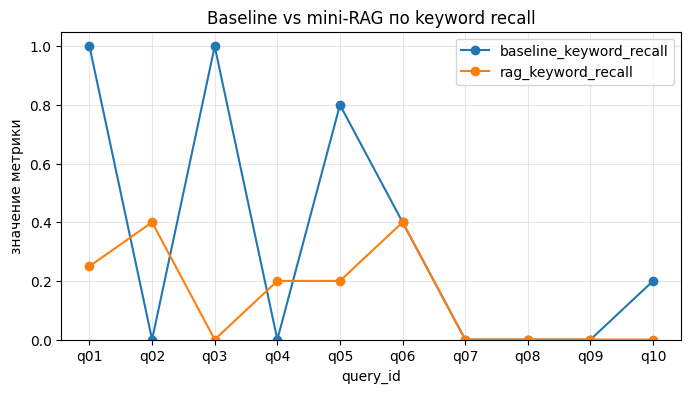

In [72]:
plt.figure(figsize=(8, 4))
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["baseline_keyword_recall"],
    marker="o",
    label="baseline_keyword_recall",
)
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["rag_keyword_recall"],
    marker="o",
    label="rag_keyword_recall",
)
plt.ylim(0, 1.05)
plt.xlabel("query_id")
plt.ylabel("значение метрики")
plt.title("Baseline vs mini-RAG по keyword recall")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [73]:
weak_cases = evaluation_df[
    evaluation_df["rag_keyword_recall"] < evaluation_df["rag_keyword_recall"].max()
].reset_index(drop=True)

display(weak_cases if len(weak_cases) > 0 else evaluation_df.head(0))

if len(weak_cases) == 0:
    print("На этом маленьком benchmark все ответы mini-RAG достигли одинакового keyword recall.")
else:
    print("Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.")


,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Почему VPN может замедлять интернет?,net_15,"net_15, net_05, net_12",1,1.0,0.25,VPN добавляет задержку из-за шифрования и марш...,VPN используется для приватности и обхода блок...
1,q03,Почему DPI может блокировать трафик?,net_07,"net_07, net_11, net_18",1,1.0,0.00,DPI (Deep Packet Inspection) — технология анал...,Это может улучшить скорость и снизить нагрузку...
2,q04,Как SNI помогает провайдерам блокировать сайты?,net_08,"net_08, net_09, net_11",1,0.0,0.20,Она позволяет провайдерам анализировать содерж...,"Он защищает данные от перехвата, но не всегда ..."
3,q05,Чем прокси отличается от VPN?,"net_05, net_06","net_05, net_12, net_15",1,0.8,0.20,"В отличие от VPN, прокси обычно работает на ур...",VPN используется для приватности и обхода блок...
4,q07,Как работает active probing?,net_20,"net_14, net_13, net_07",0,0.0,0.00,Не удалось уверенно извлечь ответ без retrieva...,В найденном контексте нет достаточно релевантн...
5,q08,Как можно определить VPN-трафик даже при шифро...,net_21,"net_05, net_12, net_16",0,0.0,0.00,"Весь трафик проходит через этот туннель, скрыв...","Весь трафик проходит через этот туннель, скрыв..."
6,q09,Что такое QUIC и чем он отличается от TCP?,"net_22, net_13","net_13, net_09, net_11",1,0.0,0.00,TCP обеспечивает надежную доставку данных с по...,"Он защищает данные от перехвата, но не всегда ..."
7,q10,Что такое port blocking?,net_23,"net_12, net_05, net_11",0,0.2,0.00,"VPN-сервисы могут хранить или не хранить логи,...",Запрос выглядит как обычный HTTPS-трафик к поп...


Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.


In [74]:
for _, row in weak_cases.iterrows():
    display(Markdown(f"### Слабый кейс: {row['query']}"))
    rag = mini_rag_answer(row["query"], artifacts=artifacts, top_k=3)
    display(Markdown(f"**Ответ mini-RAG:** {rag['answer']}"))
    display(rag["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])


### Слабый кейс: Почему VPN может замедлять интернет?

**Ответ mini-RAG:** VPN используется для приватности и обхода блокировок. VPN создает зашифрованный туннель между клиентом и сервером.

,rank,score,doc_id,title,chunk_text
0,1,0.839861,net_15,Почему VPN замедляет интернет,VPN добавляет задержку из-за шифрования и марш...
1,2,0.721856,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...
2,3,0.716639,net_12,Что такое туннелирование,Туннелирование — это способ передачи одного пр...


### Слабый кейс: Почему DPI может блокировать трафик?

**Ответ mini-RAG:** Это может улучшить скорость и снизить нагрузку. DPI (Deep Packet Inspection) — технология анализа сетевого трафика.

...

**Ответ mini-RAG:** Он защищает данные от перехвата, но не всегда скрывает метаданные, такие как SNI. TCP обеспечивает надежную доставку данных с подтверждением.

,rank,score,doc_id,title,chunk_text
0,1,0.634238,net_13,Разница между TCP и UDP,TCP обеспечивает надежную доставку данных с по...
1,2,0.464218,net_09,TLS и шифрование,"TLS — это протокол шифрования, обеспечивающий ..."
2,3,0.420032,net_11,Обход блокировок через CDN,Некоторые системы используют CDN для маскировк...


### Слабый кейс: Что такое port blocking?

**Ответ mini-RAG:** Запрос выглядит как обычный HTTPS-трафик к популярному домену, что затрудняет его блокировку.

,rank,score,doc_id,title,chunk_text
0,1,0.542499,net_12,Что такое туннелирование,Туннелирование — это способ передачи одного пр...
1,2,0.509576,net_05,Что такое VPN,VPN создает зашифрованный туннель между клиент...
2,3,0.500753,net_11,Обход блокировок через CDN,Некоторые системы используют CDN для маскировк...
